# Q3 — Feature Engineering + Regression Pipeline

## 1. Date Feature Engineering

In [1]:
import pandas as pd

df = pd.read_csv("C:/Users/Shivangi/OneDrive/Desktop/assignment 4 A and B/q3_retail_promotions.csv")

# Convert to datetime
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Extract features
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek

# Month end flag
df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day_of_week,is_month_end
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224,2022,1,5,0
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,5,0
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,6,0
3,2022-01-02,17,small,urban,free_gift,1,0,7,259,2022,1,6,0
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277,2022,1,0,0


Extracted year, month, and day_of_week from transaction_date to capture temporal patterns

Created a binary feature is_month_end to identify end-of-month periods when sales often increase due to salary cycles or promotions

These features help the model learn seasonality and purchasing behavior trends

## 2. Temporal Train-Test Split

In [4]:
# Sort by date
df = df.sort_values(by='transaction_date')

# Split (80-20)
split_index = int(len(df) * 0.8)

train = df.iloc[:split_index]
test = df.iloc[split_index:]

X_train = train.drop('items_sold', axis=1)
y_train = train['items_sold']

X_test = test.drop('items_sold', axis=1)
y_test = test['items_sold']

Why Not Random Split

Random splitting breaks the temporal order of data, causing the model to learn from future information

This leads to data leakage, where the model performs unrealistically well

A time-based split ensures that the model is trained on past data and tested on future data, mimicking real-world scenarios

## 3. Preprocessing Pipeline

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Drop date column (already used)
X_train = X_train.drop('transaction_date', axis=1)
X_test = X_test.drop('transaction_date', axis=1)

categorical_cols = ['promotion_type', 'location_type', 'store_size']
numerical_cols = [col for col in X_train.columns if col not in categorical_cols]

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first'), categorical_cols),
    ('num', StandardScaler(), numerical_cols)
])

## 4. Model Training + Evaluation

In [7]:
# Linear Regression Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)

y_pred_lr = lr_pipeline.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)

print("Linear Regression RMSE:", rmse_lr)
print("Linear Regression MAE:", mae_lr)

Linear Regression RMSE: 27.121451164890605
Linear Regression MAE: 21.0529266745884


In [8]:
# Random Forest Pipeline

from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print("Random Forest RMSE:", rmse_rf)
print("Random Forest MAE:", mae_rf)

Random Forest RMSE: 31.739760862100606
Random Forest MAE: 25.190375000000003


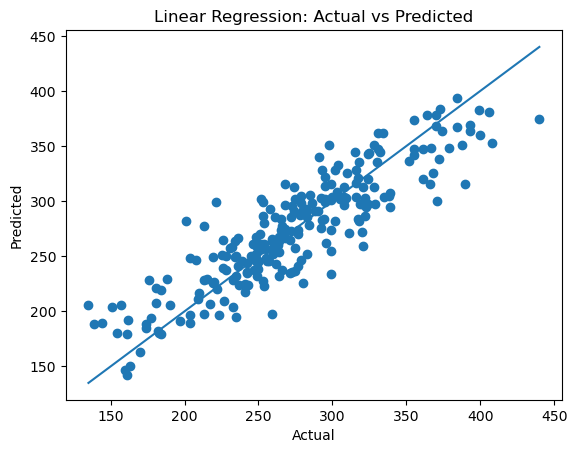

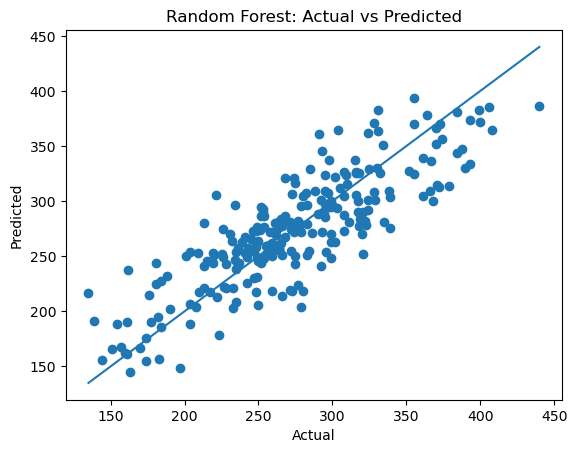

In [9]:
# Parity Plot
import matplotlib.pyplot as plt

# Linear Regression Plot
plt.scatter(y_test, y_pred_lr)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.title("Linear Regression: Actual vs Predicted")
plt.xlabel("Actual")
plt.ylabel("Predicted")d
plt.show()

# Random Forest Plot
plt.scatter(y_test, y_pred_rf)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.title("Random Forest: Actual vs Predicted")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

 Model Performance Comparison

1. Linear Regression Performance
- RMSE: 27.12  
- MAE: 21.05  
- Lower error values indicate better prediction accuracy.

2. Random Forest Performance
- RMSE: 31.74  
- MAE: 25.19  
- Higher errors compared to Linear Regression.

3. Comparison
- Linear Regression outperforms Random Forest on both RMSE and MAE.
- This suggests the relationship in the data is likely more linear, and a simple model fits better.

4. Conclusion
- Although Random Forest can capture complex patterns, in this case it does not improve performance.
- Linear Regression is the better model for this dataset due to lower prediction error.

Even though the parity plot may visually suggest Random Forest performs well, 
the evaluation metrics (RMSE, MAE) clearly show that Linear Regression provides more accurate predictions.

In [10]:
# Feature Importance (Random Forest)

# Get feature names after preprocessing
ohe = rf_pipeline.named_steps['preprocessor'].named_transformers_['cat']
cat_features = ohe.get_feature_names_out(categorical_cols)

all_features = list(cat_features) + numerical_cols

importances = rf_pipeline.named_steps['model'].feature_importances_

feat_imp = pd.DataFrame({
    'feature': all_features,
    'importance': importances
}).sort_values(by='importance', ascending=False)

feat_imp.head(5)

,feature,importance
7,store_size_small,0.185736
10,is_festival,0.174141
5,location_type_urban,0.141740
14,day_of_week,0.089409
9,is_weekend,0.064742


Store size has the strongest impact on sales

Festivals significantly boost demand

Urban stores show higher customer activity

Weekly patterns (weekends & specific days) influence sales trends

Overall, sales are influenced by a combination of store characteristics, location, and time-based factors, emphasizing the need for dynamic inventory and promotion strategies aligned with customer behavior patterns
